In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path
import numpy as np 

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2024-05-s26/accuracy-basis-multiple-layers/run2")

# CIFAR100

In [3]:
def load(dataset, model, basis_name):
    filename = ARTIFACT_DIR / dataset / model / basis_name / "stats.csv"
    return pd.read_csv(filename)

load("cifar100-people", "cifar100-resnet18-v1", "pcalookahead")

,basis_name,layer_dimensions,ref_acc,acc
0,pcalookahead,"(64, 56, 48, 40)",0.62,0.614
1,pcalookahead,"(48, 40, 32, 24)",0.62,0.620
2,pcalookahead,"(40, 32, 24, 16)",0.62,0.618
3,pcalookahead,"(32, 24, 16, 8)",0.62,0.620
4,pcalookahead,"(24, 16, 8, 4)",0.62,0.588


In [4]:
CIFAR100_CLASSES = """
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

In [5]:
CIFAR100_CLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

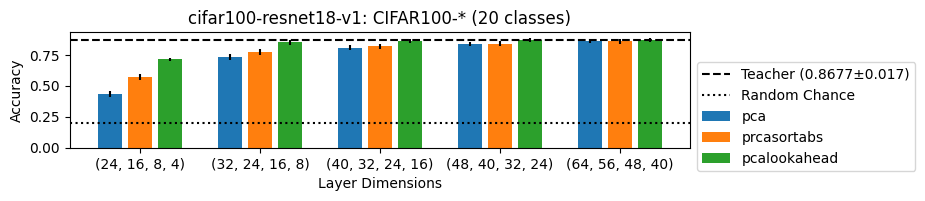

In [15]:
def viz_cifar100_superclass(model_name):

    count = len(CIFAR100_CLASSES)

    arr_bases = ["pca", "prcasortabs", "pcalookahead",]
    nbases = len(arr_bases)

    plt.figure(figsize=(8, 1.5))
    plt.title(f"{model_name}: CIFAR100-* ({count} classes)")
    
    for bix, basis in enumerate(arr_bases):
        arr_dfs = []
        for dataset_name in CIFAR100_CLASSES:
            arr_dfs.append(load(dataset_name, model_name, basis))

        df = pd.concat(arr_dfs) \
            .groupby("layer_dimensions") \
            .agg(dict(
                ref_acc=["mean", "std", "count"],
                acc=["mean", "std", "count"]
             )) \
            .reset_index()
        
        np.testing.assert_allclose(
            df["acc"]["count"], 
            count
        )
        np.testing.assert_allclose(
            df["ref_acc"]["count"], 
            count
        )
        
        if bix == 0:
            teacher_mean_acc = df["ref_acc"]["mean"].values[0]
            teacher_mean_stderr = df["ref_acc"]["std"].values[0] / (count**0.5)
            plt.axhline(teacher_mean_acc, ls="--", color="k", label=f"Teacher ({teacher_mean_acc:.4f}±{teacher_mean_stderr:.3f})")
            plt.axhline(1/5, ls=":", label="Random Chance", color="k")
        ticks = np.arange(df["layer_dimensions"].shape[0]) * (nbases + 1)
        plt.bar(
            ticks + bix, 
            df["acc"]["mean"],
            yerr=df["acc"]["std"] / (count ** 0.5),
            label=basis
        )
        if bix == 0:
            plt.xticks(ticks + 1, df["layer_dimensions"])
    plt.ylabel("Accuracy")
    plt.xlabel("Layer Dimensions")
    plt.legend(bbox_to_anchor=[1, 0.8])

viz_cifar100_superclass("cifar100-resnet18-v1")

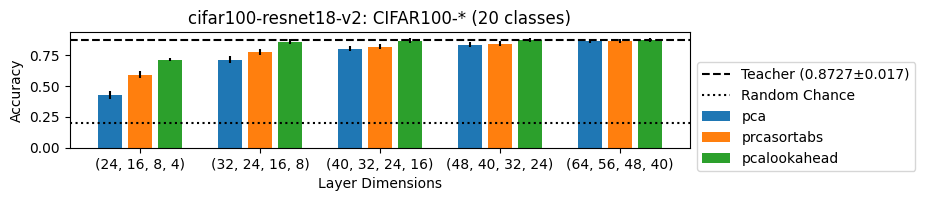

In [16]:
viz_cifar100_superclass("cifar100-resnet18-v2")

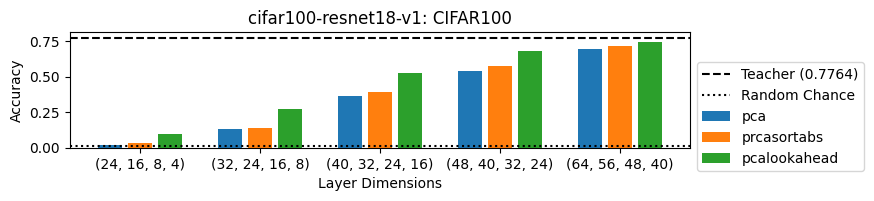

In [18]:
def viz_cifar100(model_name):

    dataset_name = "cifar100"
    count = len(CIFAR100_CLASSES)

    arr_bases = ["pca", "prcasortabs", "pcalookahead",]
    nbases = len(arr_bases)

    plt.figure(figsize=(8, 1.5))
    plt.title(f"{model_name}: CIFAR100")
    
    for bix, basis in enumerate(arr_bases):
        df = load(dataset_name, model_name, basis) \
            .groupby("layer_dimensions") \
            .agg(dict(
                ref_acc=["mean", "std", "count"],
                acc=["mean", "std", "count"]
             )) \
            .reset_index()
        
       
        if bix == 0:
            teacher_mean_acc = df["ref_acc"]["mean"].values[0]
            plt.axhline(teacher_mean_acc, ls="--", color="k", label=f"Teacher ({teacher_mean_acc:.4f})")
            plt.axhline(1/100, ls=":", label="Random Chance", color="k")

        ticks = np.arange(df["layer_dimensions"].shape[0]) * (nbases + 1)
        plt.bar(
            ticks + bix, 
            df["acc"]["mean"],
            label=basis
        )
        if bix == 0:
            plt.xticks(ticks + 1, df["layer_dimensions"])
    plt.ylabel("Accuracy")
    plt.xlabel("Layer Dimensions")
    plt.legend(bbox_to_anchor=[1, 0.8])

viz_cifar100("cifar100-resnet18-v1")

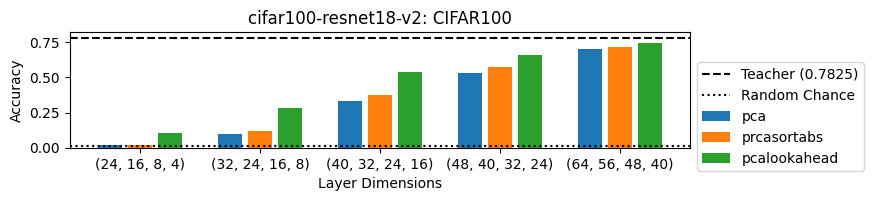

In [20]:
viz_cifar100("cifar100-resnet18-v2")

# ImageNet

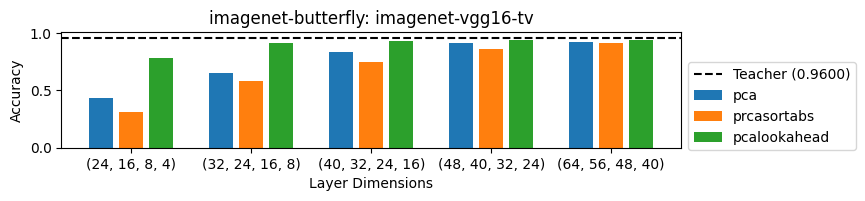

In [8]:
def viz_imagenet(dataset_name, model_name):

    count = len(CIFAR100_CLASSES)

    arr_bases = ["pca", "prcasortabs", "pcalookahead",]
    nbases = len(arr_bases)

    plt.figure(figsize=(8, 1.5))
    plt.title(f"{dataset_name}: {model_name}")
    
    for bix, basis in enumerate(arr_bases): 
        df = load(dataset_name, model_name, basis) \
            .groupby("layer_dimensions") \
            .agg(dict(
                ref_acc=["mean", "count"],
                acc=["mean", "count"]
             )) \
            .reset_index()

        if bix == 0:
            teacher_mean_acc = df["ref_acc"]["mean"].values[0]
            plt.axhline(teacher_mean_acc, ls="--", color="k", label=f"Teacher ({teacher_mean_acc:.4f})")

        ticks = np.arange(df["layer_dimensions"].shape[0]) * (nbases + 1)
        plt.bar(
            ticks + bix, 
            df["acc"]["mean"],
            label=basis
        )
        if bix == 0:
            plt.xticks(ticks + 1, df["layer_dimensions"])
    plt.ylabel("Accuracy")
    plt.xlabel("Layer Dimensions")
    plt.legend(bbox_to_anchor=[1, 0.8])
    
viz_imagenet("imagenet-butterfly", "imagenet-vgg16-tv")

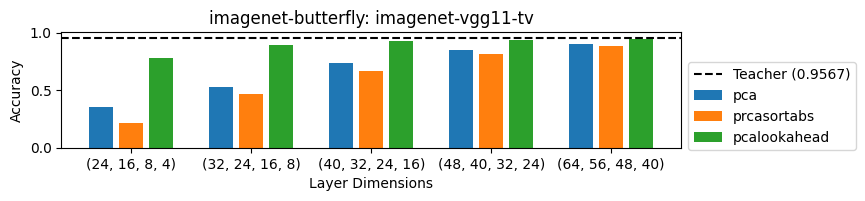

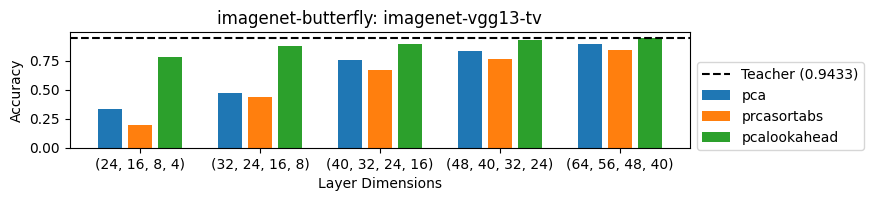

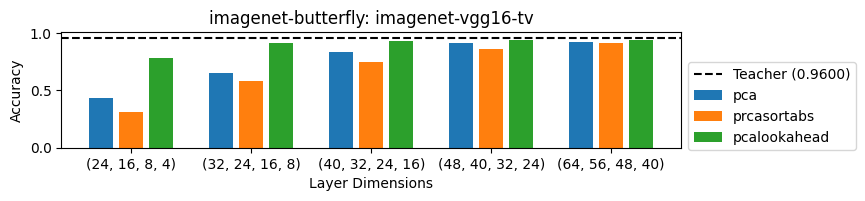

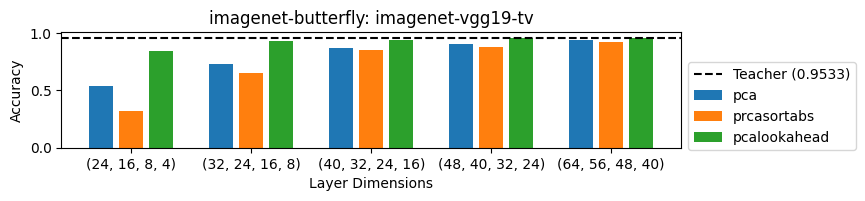

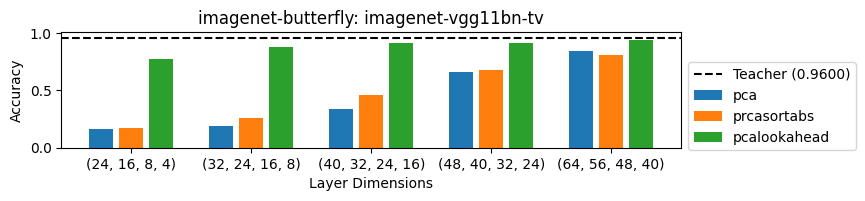

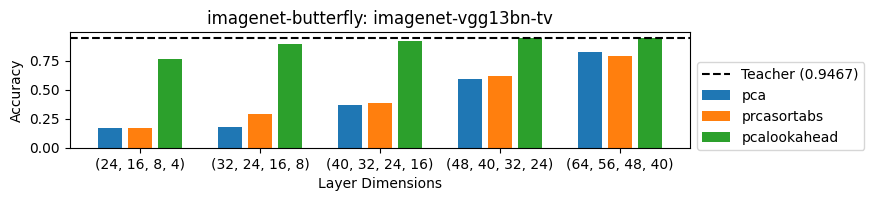

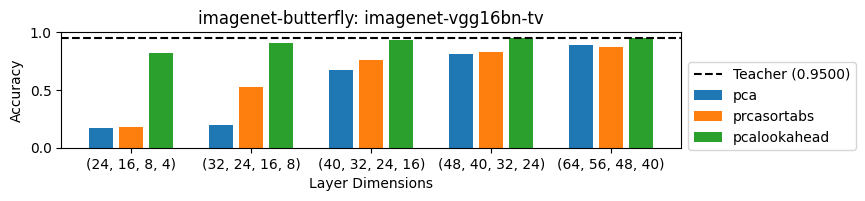

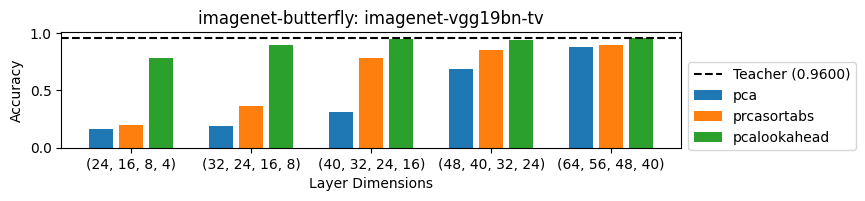

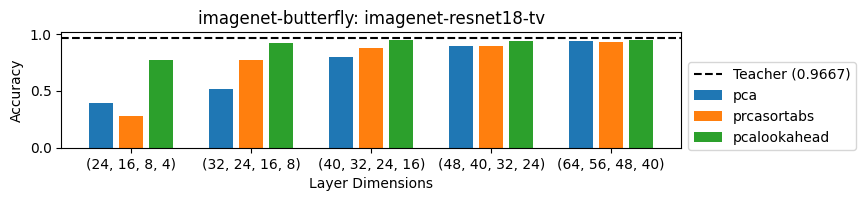

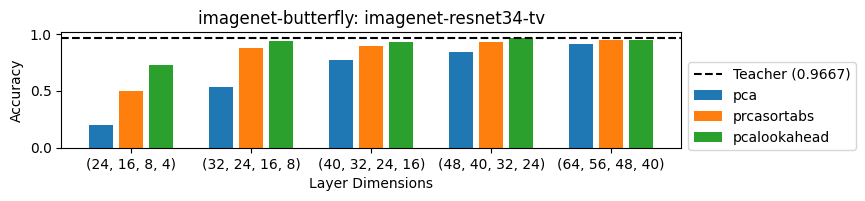

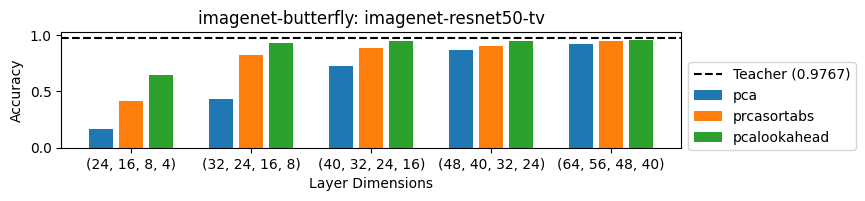

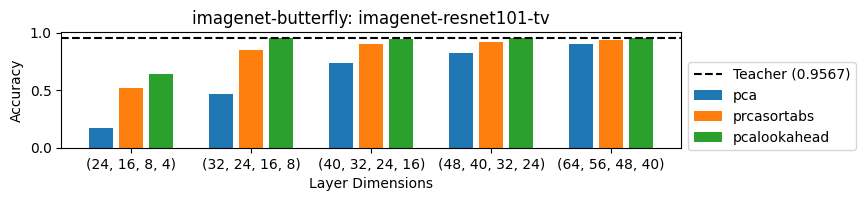

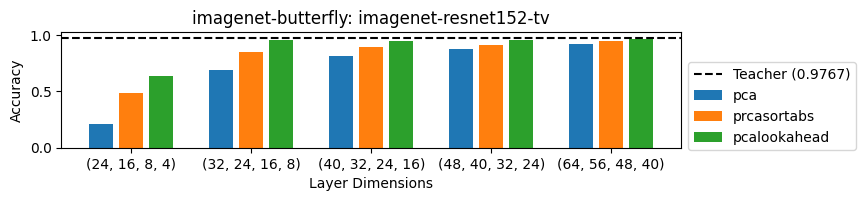

In [9]:
for model_name in [
    "imagenet-vgg11-tv",
    "imagenet-vgg13-tv",
    "imagenet-vgg16-tv",
    "imagenet-vgg19-tv",

    "imagenet-vgg11bn-tv",
    "imagenet-vgg13bn-tv",
    "imagenet-vgg16bn-tv",
    "imagenet-vgg19bn-tv",

    "imagenet-resnet18-tv",
    "imagenet-resnet34-tv",
    "imagenet-resnet50-tv",
    "imagenet-resnet101-tv",
    "imagenet-resnet152-tv",
]:
    viz_imagenet("imagenet-butterfly", model_name)

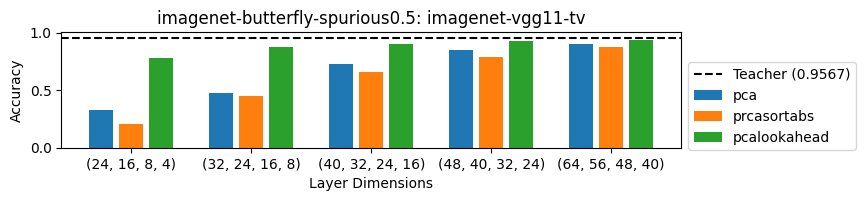

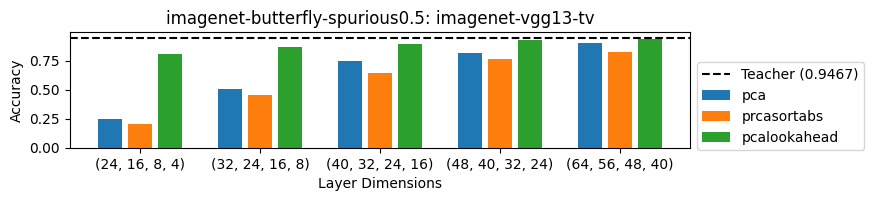

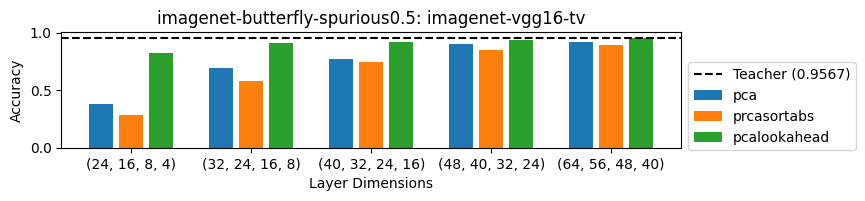

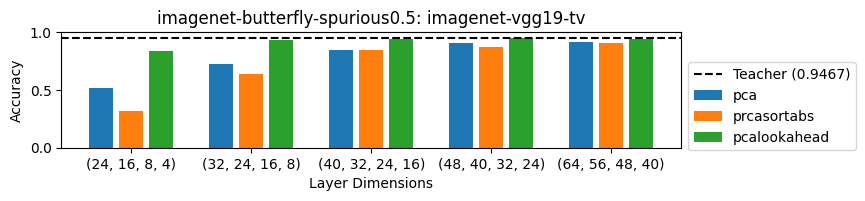

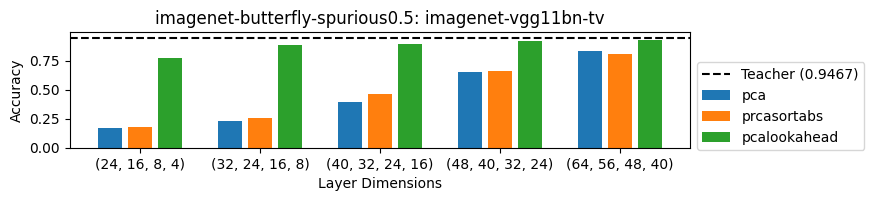

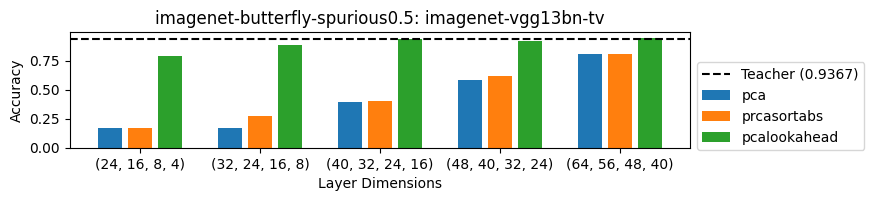

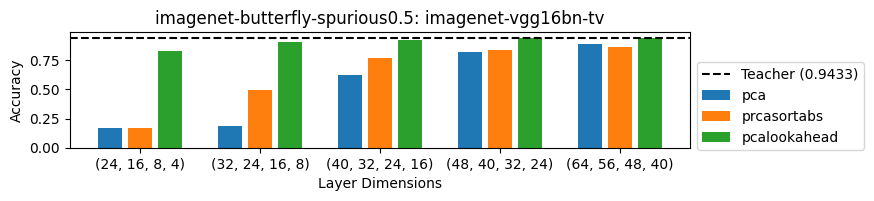

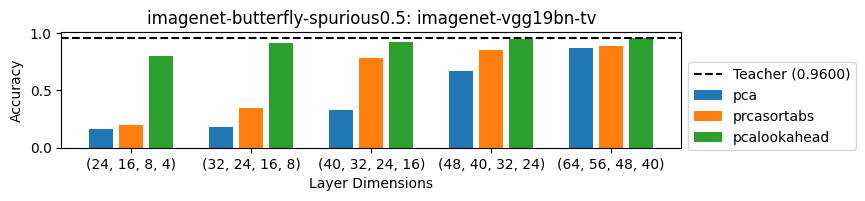

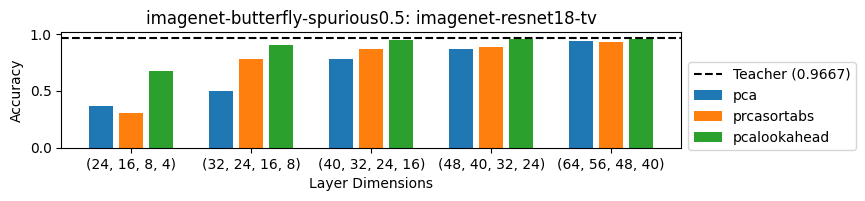

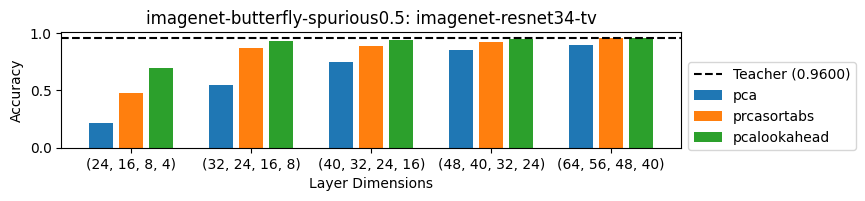

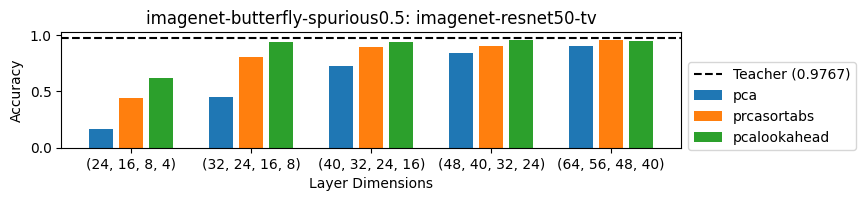

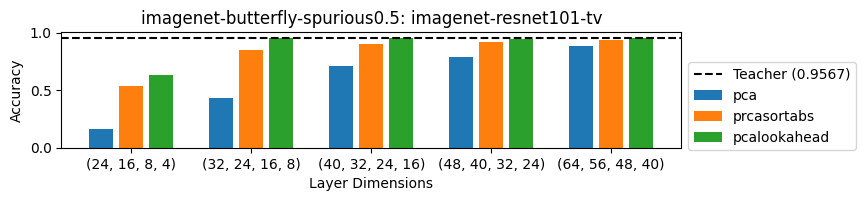

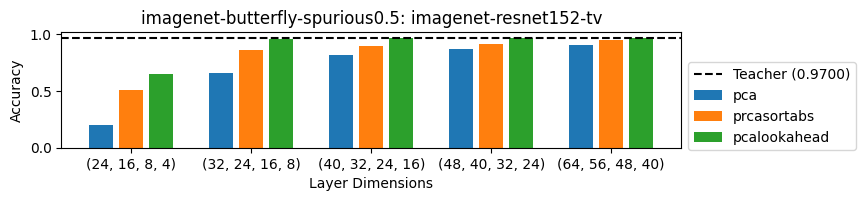

In [10]:
for model_name in [
    "imagenet-vgg11-tv",
    "imagenet-vgg13-tv",
    "imagenet-vgg16-tv",
    "imagenet-vgg19-tv",

    "imagenet-vgg11bn-tv",
    "imagenet-vgg13bn-tv",
    "imagenet-vgg16bn-tv",
    "imagenet-vgg19bn-tv",

    "imagenet-resnet18-tv",
    "imagenet-resnet34-tv",
    "imagenet-resnet50-tv",
    "imagenet-resnet101-tv",
    "imagenet-resnet152-tv",
]:
    viz_imagenet("imagenet-butterfly-spurious0.5", model_name)